In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data
The original data came from Dataset: UCI Machine Learning Repository - Moro, S., Rita, P., & Cortez, P. (2014) - Bank Marketing Dataset
I will use the bank-additional-full variant.

In [5]:
df=pd.read_csv('../data/raw_data/bank-additional-full.csv', sep=';')

In [6]:
df.shape

(41188, 21)

In [7]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [9]:
df.dtypes

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

## DATA DICTIONARY


| Column | Dtype | Description |
|--------|------|-------------|
| age | int | Age in years |
| job | string | Job type |
| marital | string | Marital status (single, married, divorced) |
| education | string | Education level (illiterate, basic.4y, basic.6y, basic.9y, high.school, professional.course, university.degree, unknown) |
| default | string | Has credit in default? (no, yes, unknown) |
| housing | string | Has housing loan? (no, yes, unknown) |
| loan | string | Has personal loan? (no, yes, unknown) |
| contact | string | Contact communication type (cellular, telephone) |
| month | string | Last contact month of year |
| day_of_week | string | Last contact day of the week |
| duration | int | Last contact duration in seconds |
| campaign | int | Number of contacts performed during this campaign |
| pdays | int | Days since client was last contacted in previous campaign (999 = never contacted) |
| previous | int | Number of contacts performed before this campaign |
| poutcome | string | Outcome of previous marketing campaign (failure, nonexistent, success) |
| emp.var.rate | float | Employment variation rate — quarterly indicator |
| cons.price.idx | float | Consumer price index — monthly indicator |
| cons.conf.idx | float | Consumer confidence index — monthly indicator |
| euribor3m | float | Euribor 3 month rate — daily indicator |
| nr.employed | float | Number of employees — quarterly indicator |
| y | string | **TARGET** — has the client subscribed a term deposit? (yes, no) |

In [10]:
# Target distribution
df['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

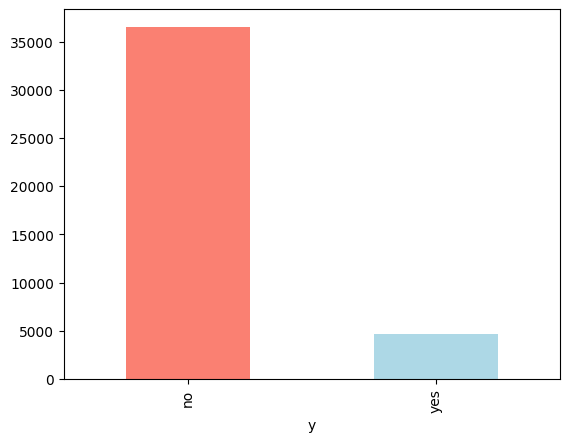

In [16]:
df['y'].value_counts().plot(kind='bar', color=['salmon', 'lightblue']);

# Save fig.
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.close

## Target distribution

The dataset is heavily imbalanced:
- **no**: 36,548 (88.7%)
- **yes**: 4,640 (11.3%)

This imbalance must be addressed before training the model.

Possible strategies: class_weight parameter, SMOTE oversampling, or undersampling.

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [13]:
# No missing values
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [16]:
# Null values are none, however there are many 'unknown' values which can be treated as null
unknown_values=(df=='unknown').sum()
unknown_values

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

### pdays
Value 999 indicates the client was never previously contacted.

This is not a null value, it carries meaningful information.

I will create a binary column `previously_contacted` in the cleaning notebook.

## Missing Values Summary

No true NaN values found. Missing data is also a strings:

- `unknown`: found in job (330), marital (80), education (1731), 
  default (8597), housing (990), loan (990)

### Cleaning Strategy
- `default`: keep 'unknown' as separate category (20% of data, it's too large to drop)
- `education`: impute with mode or keep as separate category
- `job`, `marital`: keep as separate category (small percentage)
- `housing`, `loan`: keep as separate category

### Feature Engineering Ideas (to apply in notebook later)
- Check overlap between housing and loan unknown clients, maybe we can find some patterns

In [18]:
# Fast descriptive statistics
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Descriptive Statistics - Key Observation

- **'age' max = 98**: to verify
- **'duration' = 0**: calls with zero duration, so it's not a call — likely errors, to remove in cleaning
- **'campaign' max = 56**: an outlier for sure, client contacted 56 times during the same campaign
- **'pdays' 75th percentile = 999**: most clients never previously contacted

In [25]:
# Number of calls with a duration = 0
print(f"Duration=0: {(df['duration']==0).sum()}")

Duration=0: 4


In [26]:
# Number of client with age > 90
print(f"Age > 90: {(df['age']>90).sum()}")

Age > 90: 10


- `duration = 0`: 4 records found - to remove in cleaning (no contact made)
- `age > 90`: 10 records found - likely real, keep but monitor

In [27]:
# Check for duplicated rows
print(f"Duplicated rows: {df.duplicated().sum()}")

Duplicated rows: 12


In [28]:
# Visualize the duplicated rows
df[df.duplicated(keep=False)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


In [32]:
# Distribution of categorical columns
for col in df.select_dtypes(include='str').columns:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("-" * 40)
    


job:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
----------------------------------------

marital:
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
----------------------------------------

education:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64
----------------------------------------

default:
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64
----------------------------------------

housing:
housing
yes        2157

## Categorical Variables — Key Observations

- `default`: only 3 "yes" values - useless as predictor, consider dropping
- `education`: "illiterate" has only 18 cases - not relevant, consider dropping
- `poutcome`: 86% "nonexistent" - it's strongly correlated with pdays=999, to verify numerically
- `month`: May dominates (13,769 contacts) - strong seasonal pattern
- `day_of_week`: uniform distribution here

In [35]:
# Correlation between numerical columns (only testual
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()
print(corr_matrix)

                     age  duration  campaign     pdays  previous  \
age             1.000000 -0.000866  0.004594 -0.034369  0.024365   
duration       -0.000866  1.000000 -0.071699 -0.047577  0.020640   
campaign        0.004594 -0.071699  1.000000  0.052584 -0.079141   
pdays          -0.034369 -0.047577  0.052584  1.000000 -0.587514   
previous        0.024365  0.020640 -0.079141 -0.587514  1.000000   
emp.var.rate   -0.000371 -0.027968  0.150754  0.271004 -0.420489   
cons.price.idx  0.000857  0.005312  0.127836  0.078889 -0.203130   
cons.conf.idx   0.129372 -0.008173 -0.013733 -0.091342 -0.050936   
euribor3m       0.010767 -0.032897  0.135133  0.296899 -0.454494   
nr.employed    -0.017725 -0.044703  0.144095  0.372605 -0.501333   

                emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  \
age                -0.000371        0.000857       0.129372   0.010767   
duration           -0.027968        0.005312      -0.008173  -0.032897   
campaign            0.150754 